Title: "White House Logs Analysis" <br>
Class: "DSC640-T301 Data Presentation & Visualizat (2263-1)<br>
Student: "Roshan GC" <br>
Date: "01/17/2026"

# 1. Description: <br>
I am creating 6 visualization from given 5 monthly datasets (May, July, August, September and October 2022) of open source white House Logs data. 

# 2. Loading Data

In [2]:
# importing required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
# dataset and paths
paths = [
    "/Users/roshan/DSC640/white-house-visitors-data/2022.06_WAVES-ACCESS-RECORDS.csv",
    "/Users/roshan/DSC640/white-house-visitors-data/2022.07_WAVES-ACCESS-RECORDS.csv",
    "/Users/roshan/DSC640/white-house-visitors-data/2022.08_WAVES-ACCESS-RECORDS.csv",
    "/Users/roshan/DSC640/white-house-visitors-data/2022.09_WAVES-ACCESS-RECORDS.csv",
    "/Users/roshan/DSC640/white-house-visitors-data/2022.10_WAVES-ACCESS-RECORDS.csv",
]


dfs = []

for path in paths:
    df = pd.read_csv(path)
    dfs.append(df)

combined_data = pd.concat(dfs)
combined_data.head()


/var/folders/fj/1y30smkn19d0x1r6g3zr71d40000gn/T/ipykernel_7769/1430451392.py:14: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/fj/1y30smkn19d0x1r6g3zr71d40000gn/T/ipykernel_7769/1430451392.py:14: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,Last Name,First Name,Middle Initial,UIN,BDGNBR,Access Type,TOA,POA,TOD,POD,...,Last Entry Date,Terminal Suffix,Visitee Last Name,Visitee First Name,Meeting Location,Meeting Room,Caller Last Name,Caller First Name,CALLER_ROOM,RELEASEDATE
0,AANGEENBRUG,ELIZABETH,N,U55489,NaN,VA,Jun 16 2022 2:13PM,NaN,NaN,NaN,...,6/16/2022 11:17,JL,POTUS,NaN,WH,RES - State Floor,LEE,JANICE,NaN,10/4/2022
1,AARFLOT,ELIN,J,U52410,198183.0,VA,Jun 2 2022 9:34AM,NaN,NaN,B04,...,5/31/2022 10:33,LP,Raj Panjabi,Dr.,OEOB,228,PHONHARATH,LEETHA,NaN,10/4/2022
2,AARHUS,PRESTON,M,U54582,NaN,VA,NaN,NaN,NaN,NaN,...,6/10/2022 6:43,VW,Office,Visitors,WH,EW TOUR,WAVES,VISITORSOFFICE,NaN,10/4/2022
3,AARHUS,PRESTON,M,U56040,NaN,VA,Jun 18 2022 10:33AM,NaN,NaN,NaN,...,6/17/2022 19:33,EK,KNIGHT,EVA,WH,EW TOUR,KNIGHT,EVA,NaN,10/4/2022
4,AAS,SVEN,E,U57600,197687.0,VA,Jun 28 2022 10:40AM,NaN,NaN,A05,...,6/28/2022 9:19,DR,Rodriguez,Drew,OEOB,260,RODRIGUEZ,DREW,NaN,10/4/2022


## 3. Cleaning Data

In [21]:
# standardizing the column names
standard_map = {
    'LAST NAME':'NAMELAST',
    'FIRST NAME':'NAMEFIRST',
    'MIDDLE INITIAL':'NAMEMID',
    'ACCESS TYPE':'ACCESS_TYPE',
    'APPOINTMENT MADE DATE':'APPT_MADE_DATE',
    'APPOINTMENT START DATE':'APPT_START_DATE',
    'APPOINTMENT END DATE':'APPT_END_DATE',
    'APPOINTMENT CANCEL DATE':'APPT_CANCEL_DATE',
    'TOTAL PEOPLE':'TOTAL_PEOPLE',
    'LAST UPDATED BY':'LAST_UPDATEDBY',
    'LAST ENTRY DATE':'LASTENTRYDATE',
    'TERMINAL SUFFIX':'TERMINAL_SUFFIX',
    'VISITEE LAST NAME':'VISITEE_NAMELAST',
    'VISITEE FIRST NAME':'VISITEE_NAMEFIRST',
    'MEETING LOCATION':'MEETING_LOC',
    'MEETING ROOM':'MEETING_ROOM',
    'CALLER LAST NAME':'CALLER_NAME_LAST',
    'CALLER FIRST NAME':'CALLER_NAME_FIRST',
    'CALLER ROOM':'CALLER_ROOM',
}

date_cols = ['APPT_MADE_DATE','APPT_START_DATE','APPT_END_DATE','APPT_CANCEL_DATE','LASTENTRYDATE','RELEASEDATE']


In [22]:
def load_clean(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)

    # Normalizing headers
    new_cols = {}
    for c in df.columns:
        c_strip = c.strip()
        key = c_strip.upper()
        new_cols[c] = standard_map.get(key, key)
    df = df.rename(columns=new_cols)

    # Ensuring the consistent schema
    standard_cols = ['NAMELAST','NAMEFIRST','NAMEMID','UIN','BDGNBR','ACCESS_TYPE','TOA','POA','TOD','POD',
                     'APPT_MADE_DATE','APPT_START_DATE','APPT_END_DATE','APPT_CANCEL_DATE','TOTAL_PEOPLE',
                     'LAST_UPDATEDBY','POST','LASTENTRYDATE','TERMINAL_SUFFIX','VISITEE_NAMELAST',
                     'VISITEE_NAMEFIRST','MEETING_LOC','MEETING_ROOM','CALLER_NAME_LAST','CALLER_NAME_FIRST',
                     'CALLER_ROOM','RELEASEDATE']
    for c in standard_cols:
        if c not in df.columns:
            df[c] = np.nan

    # Parsing the dates
    for c in date_cols:
        df[c] = pd.to_datetime(df[c], errors='coerce')

    df['TOTAL_PEOPLE'] = pd.to_numeric(df['TOTAL_PEOPLE'], errors='coerce')
    df['SOURCE_FILE'] = os.path.basename(path)
    return df[standard_cols + ['SOURCE_FILE']]

raw = pd.concat([load_clean(p) for p in paths], ignore_index=True)

df = raw[raw['APPT_START_DATE'].notna()].copy()
df['IS_CANCELED'] = df['APPT_CANCEL_DATE'].notna()
df = df[~df['IS_CANCELED']].copy()

# Derived fields
df['DATE'] = df['APPT_START_DATE'].dt.date
df['MONTH'] = df['APPT_START_DATE'].dt.to_period('M').dt.to_timestamp()
df['HOUR'] = df['APPT_START_DATE'].dt.hour
df['DOW'] = df['APPT_START_DATE'].dt.day_name()
df['LEAD_DAYS'] = (df['APPT_START_DATE'] - df['APPT_MADE_DATE']).dt.total_seconds()/(24*3600)
df['MEETING_LOC'] = df['MEETING_LOC'].fillna('UNKNOWN')

df.shape

(164724, 34)

## 4. Visualization


In [23]:
out_dir = "wh_logs_outputs"
os.makedirs(out_dir, exist_ok=True)

def save_fig(name: str):
    path = os.path.join(out_dir, name)
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    return path

fig_paths = {}


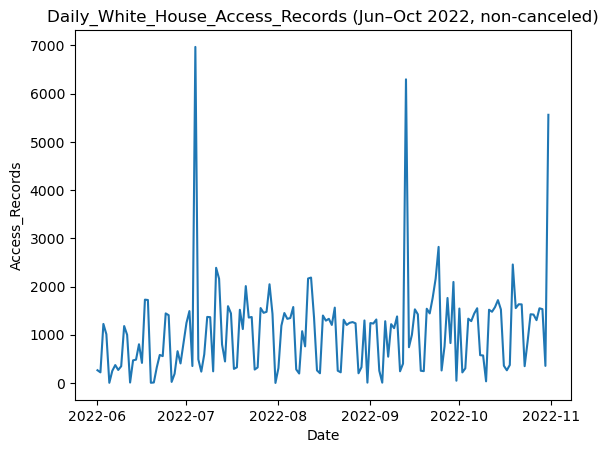

In [31]:
# Plot 1 — Line chart with daily access records
daily = df.groupby('DATE').size().reset_index(name='access_records')

plt.figure()
plt.plot(pd.to_datetime(daily['DATE']), daily['access_records'])
plt.title("Daily_White_House_Access_Records (Jun–Oct 2022, non-canceled)")
plt.xlabel("Date")
plt.ylabel("Access_Records")
plt.show()

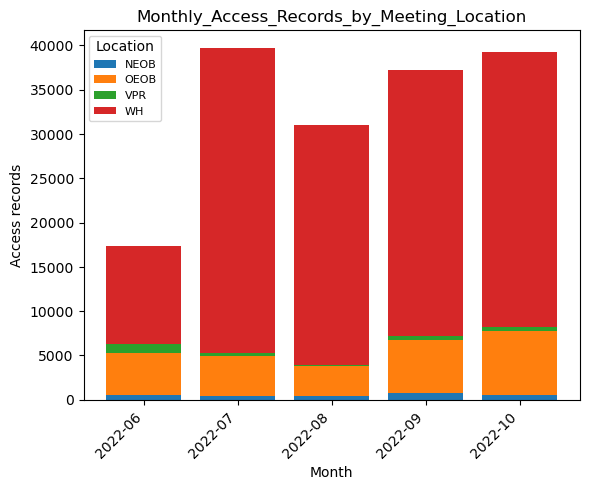

In [25]:
# Plot 2 — Stacked bar with time
monthly_loc = df.groupby(['MONTH','MEETING_LOC']).size().reset_index(name='access_records')
pivot = monthly_loc.pivot(index='MONTH', columns='MEETING_LOC', values='access_records').fillna(0).sort_index()

plt.figure()
bottom = np.zeros(len(pivot))
x = np.arange(len(pivot.index))
for col in pivot.columns:
    plt.bar(x, pivot[col].values, bottom=bottom, label=str(col))
    bottom += pivot[col].values

plt.title("Monthly_Access_Records_by_Meeting_Location")
plt.xlabel("Month")
plt.ylabel("Access records")
plt.xticks(x, [d.strftime("%Y-%m") for d in pivot.index], rotation=45, ha='right')
plt.legend(title="Location", fontsize=8)
plt.show()

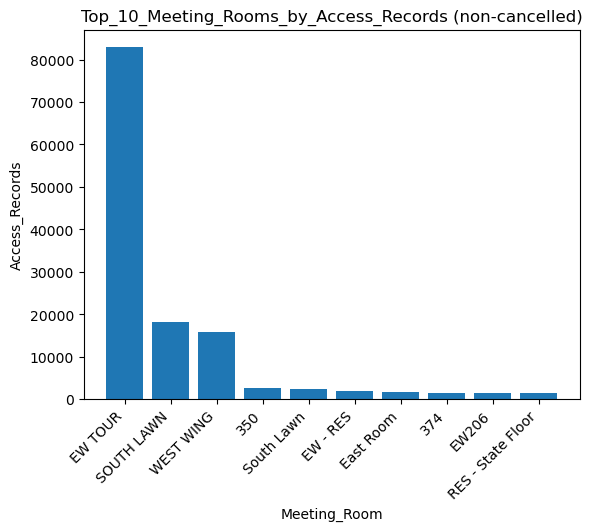

In [26]:
# Plot 3 — Bar chart
top_rooms = (df[df['MEETING_ROOM'].notna() & (df['MEETING_ROOM'].astype(str).str.strip()!="")]
             .groupby('MEETING_ROOM').size().sort_values(ascending=False).head(10))

plt.figure()
plt.bar(top_rooms.index.astype(str), top_rooms.values)
plt.title("Top_10_Meeting_Rooms_by_Access_Records (non-cancelled)")
plt.xlabel("Meeting_Room")
plt.ylabel("Access_Records")
plt.xticks(rotation=45, ha='right')
plt.show()

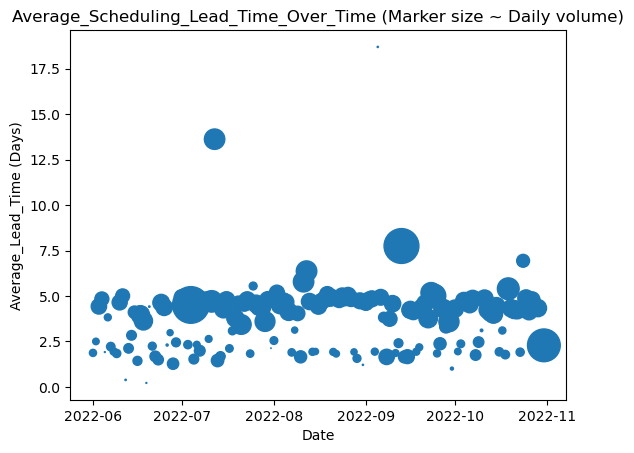

In [28]:
# Plot 4 — Scatterplot with time
daily_lt = df.groupby('DATE').agg(access_records=('UIN','size'),
                                 avg_lead_days=('LEAD_DAYS','mean')).reset_index()

plt.figure()
plt.scatter(pd.to_datetime(daily_lt['DATE']), daily_lt['avg_lead_days'], s=daily_lt['access_records']/10)
plt.title("Average_Scheduling_Lead_Time_Over_Time (Marker size ~ Daily volume)")
plt.xlabel("Date")
plt.ylabel("Average_Lead_Time (Days)")
plt.show()

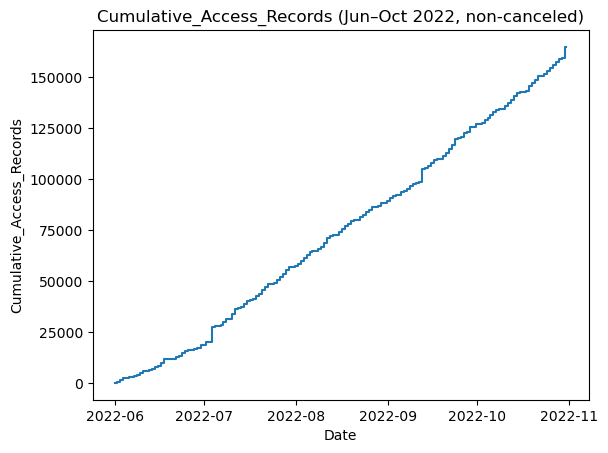

In [29]:
# Plot 5 — Step chart with cumulative access records
daily_sorted = daily.sort_values('DATE').copy()
daily_sorted['cumulative_records'] = daily_sorted['access_records'].cumsum()

plt.figure()
plt.step(pd.to_datetime(daily_sorted['DATE']), daily_sorted['cumulative_records'], where='mid')
plt.title("Cumulative_Access_Records (Jun–Oct 2022, non-canceled)")
plt.xlabel("Date")
plt.ylabel("Cumulative_Access_Records")
plt.show()

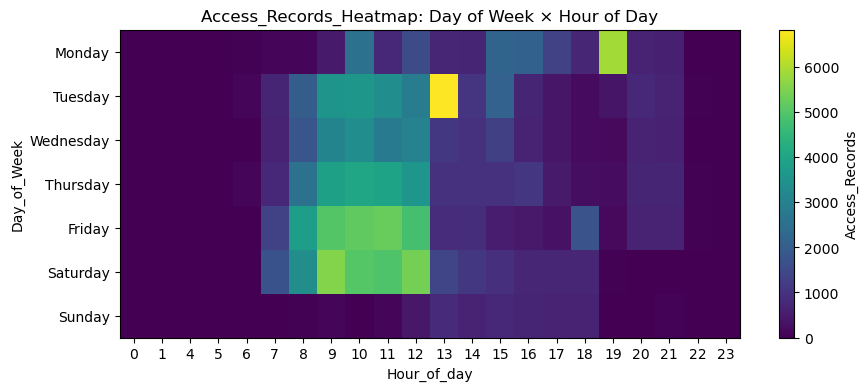

In [30]:
# Plot 6 — Heatmap
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heat = df.groupby(['DOW','HOUR']).size().reindex(dow_order, level=0).reset_index(name='count')
heat_piv = heat.pivot(index='DOW', columns='HOUR', values='count').fillna(0).reindex(dow_order)

plt.figure(figsize=(10,4))
plt.imshow(heat_piv.values, aspect='auto')
plt.title("Access_Records_Heatmap: Day of Week × Hour of Day")
plt.xlabel("Hour_of_day")
plt.ylabel("Day_of_Week")
plt.xticks(range(len(heat_piv.columns)), heat_piv.columns.tolist())
plt.yticks(range(len(heat_piv.index)), heat_piv.index.tolist())
plt.colorbar(label="Access_Records")
plt.show()

Note: Nararrtive is in separate pdf document.